# Agente Connect-4: Monte Carlo First Visit
**Universidad de La Sabana — Fundamentos de Inteligencia Artificial**  
**Facultad de Ingeniería | Felix Mohr | 2026.1**

---

Este notebook contiene el estudio completo del agente basado en **Monte Carlo First Visit**, incluyendo:
1. Implementación del agente y utilidades de evaluación
2. Análisis de desempeño contra jugador aleatorio (ambos colores)
3. Análisis de autodesempeño (agente vs. sí mismo)
4. Análisis en función de una variable de configuración (`num_rollouts`)
5. Comparación entre versiones del agente (con/sin bloqueo)
6. Propuesta de mejora

## 0. Instalación y configuración del entorno

In [1]:
# Instalar librerías necesarias si no están disponibles
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'matplotlib', 'numpy', 'tqdm', '--quiet'])

import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm
from copy import deepcopy
import warnings
warnings.filterwarnings('ignore')

# Semilla para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print('Entorno listo.')

Entorno listo.


---
## 1. Implementación del Agente y Utilidades

Se implementan aquí las clases necesarias de forma standalone (sin depender del módulo `connect4`) para poder correr los experimentos directamente en el notebook.

In [2]:
# ============================================================
# MOTOR DEL JUEGO CONNECT-4 (standalone para experimentos)
# ============================================================

def nuevo_tablero():
    """Crea un tablero vacío de Connect-4 (6 filas x 7 columnas)."""
    return np.zeros((6, 7), dtype=int)

def movimientos_disponibles(s):
    """Retorna columnas con espacio libre (celda superior == 0)."""
    return [c for c in range(7) if s[0, c] == 0]

def aplicar_movimiento(s, col, player):
    """Coloca una ficha en la columna indicada y retorna el nuevo tablero."""
    board = s.copy()
    for r in range(5, -1, -1):
        if board[r, col] == 0:
            board[r, col] = player
            break
    return board

def es_victoria(board, player):
    """Verifica si el jugador tiene 4 en línea (horizontal, vertical, diagonales)."""
    rows, cols = 6, 7
    # Horizontal
    for r in range(rows):
        for c in range(cols - 3):
            if all(board[r, c+i] == player for i in range(4)):
                return True
    # Vertical
    for r in range(rows - 3):
        for c in range(cols):
            if all(board[r+i, c] == player for i in range(4)):
                return True
    # Diagonal \
    for r in range(rows - 3):
        for c in range(cols - 3):
            if all(board[r+i, c+i] == player for i in range(4)):
                return True
    # Diagonal /
    for r in range(3, rows):
        for c in range(cols - 3):
            if all(board[r-i, c+i] == player for i in range(4)):
                return True
    return False

def get_player(s):
    """Determina de quién es el turno según cantidad de fichas en el tablero."""
    reds = np.sum(s == -1)
    yellows = np.sum(s == 1)
    return -1 if reds == yellows else 1

print('Motor del juego definido.')

Motor del juego definido.


In [3]:
# ============================================================
# AGENTE MONTE CARLO FIRST VISIT
# ============================================================

class MCFirstVisitAgent:
    """
    Agente basado en Monte Carlo First Visit para Connect-4.
    
    Idea principal:
    - Aprende el valor de (estado, accion) promediando los retornos
      obtenidos al final de episodios completos (rollouts aleatorios).
    - 'First Visit': solo la primera vez que aparece un par (s,a)
      en un episodio contribuye al promedio acumulado.
    - Combina el valor Q aprendido con nuevos rollouts en cada decisión.
    
    Parámetros configurables:
    - num_rollouts: cuántas simulaciones aleatorias por movimiento candidato
    - epsilon: probabilidad de exploración aleatoria
    - use_blocking: si True, bloquea victorias inminentes del oponente
    """

    def __init__(self, num_rollouts=5, epsilon=0.1, use_blocking=True):
        self.q_table = {}        # Q-table: (estado, accion) -> valor promedio
        self.visit_count = {}    # Contador de visitas por par (estado, accion)
        self.states_actions = [] # Historial del episodio actual
        self.num_rollouts = num_rollouts  # variable de configuración principal
        self.epsilon = epsilon            # tasa de exploración
        self.use_blocking = use_blocking  # sub-estrategia de bloqueo

    def board_to_key(self, s):
        """Convierte el tablero en una tupla hashable para usar como llave."""
        return tuple(s.flatten())

    def rollout(self, s, player):
        """
        Simulación aleatoria desde el estado s hasta el final del juego.
        Retorna: +1 si player gana, -1 si pierde, 0 si empate.
        """
        board = s.copy()
        current = player
        for _ in range(42):  # máximo 42 turnos en Connect-4
            moves = movimientos_disponibles(board)
            if not moves:
                return 0  # empate: tablero lleno
            col = random.choice(moves)  # movimiento aleatorio (Monte Carlo)
            board = aplicar_movimiento(board, col, current)
            if es_victoria(board, current):
                return 1 if current == player else -1
            current = -current  # alterna turno
        return 0

    def update_q_table(self, reward):
        """
        Actualiza la Q-table con Monte Carlo First Visit:
        solo la primera aparición de cada (estado, acción)
        en el episodio contribuye al promedio acumulado.
        """
        visited = set()  # rastrea pares ya actualizados en este episodio
        for state_key, action in self.states_actions:
            pair = (state_key, action)
            if pair in visited:
                continue  # First Visit: ignorar repeticiones en el mismo episodio
            visited.add(pair)
            n = self.visit_count.get(pair, 0)
            q = self.q_table.get(pair, 0.0)
            self.visit_count[pair] = n + 1
            # Promedio incremental: Q_nuevo = Q_viejo + (reward - Q_viejo) / (n+1)
            self.q_table[pair] = q + (reward - q) / (n + 1)
        self.states_actions = []  # limpiar historial del episodio

    def act(self, s):
        """Decide el próximo movimiento dado el estado actual del tablero."""
        player = get_player(s)
        opponent = -player
        moves = movimientos_disponibles(s)

        # a) Victoria inmediata: si podemos ganar ya, ganar
        for move in moves:
            nb = aplicar_movimiento(s, move, player)
            if es_victoria(nb, player):
                self.states_actions.append((self.board_to_key(s), move))
                self.update_q_table(1.0)  # recompensa máxima
                return int(move)

        # b) Bloqueo (sub-estrategia configurable): evitar derrota inmediata
        if self.use_blocking:
            for move in moves:
                nb = aplicar_movimiento(s, move, opponent)
                if es_victoria(nb, opponent):
                    self.states_actions.append((self.board_to_key(s), move))
                    self.update_q_table(0.5)  # recompensa por evitar derrota
                    return int(move)

        # c) Selección por Monte Carlo First Visit + Q aprendido
        state_key = self.board_to_key(s)
        best_move = None
        best_value = -float('inf')

        for move in moves:
            pair = (state_key, move)
            q_value = self.q_table.get(pair, 0.0)  # valor Q aprendido

            # Realizar rollouts aleatorios para estimar valor del movimiento
            rollout_results = []
            for _ in range(self.num_rollouts):
                nb = aplicar_movimiento(s, move, player)
                if es_victoria(nb, player):
                    rollout_results.append(1.0)
                else:
                    rollout_results.append(self.rollout(nb, player))

            avg_rollout = sum(rollout_results) / len(rollout_results)
            center_bonus = -abs(3 - move) * 0.05  # preferencia por columnas centrales

            # Combina rollout actual (60%) con historial aprendido (40%)
            total_value = 0.6 * avg_rollout + 0.4 * q_value + center_bonus

            if total_value > best_value:
                best_value = total_value
                best_move = move

        # d) Exploración epsilon-greedy
        if random.random() < self.epsilon:
            best_move = random.choice(moves)

        # Registrar y actualizar Q-table
        self.states_actions.append((state_key, best_move))
        nb = aplicar_movimiento(s, best_move, player)
        reward = self.rollout(nb, player)
        self.update_q_table(reward)

        return int(best_move)

print('Agente MCFirstVisitAgent definido.')

Agente MCFirstVisitAgent definido.


In [4]:
# ============================================================
# AGENTE ALEATORIO (oponente de referencia)
# ============================================================

class RandomAgent:
    """Jugador de referencia: elige columna al azar en cada turno."""
    def act(self, s):
        moves = movimientos_disponibles(s)
        return random.choice(moves)

print('RandomAgent definido.')

RandomAgent definido.


In [5]:
# ============================================================
# FUNCIÓN DE SIMULACIÓN DE PARTIDAS
# ============================================================

def jugar_partida(agente1, agente2, player1=-1, verbose=False):
    """
    Simula una partida completa entre dos agentes.
    
    agente1 juega con player1 (por defecto rojo = -1)
    agente2 juega con el color opuesto
    
    Retorna:
        1  si gana agente1
       -1  si gana agente2
        0  si empate
    """
    board = nuevo_tablero()
    player2 = -player1
    current_player = -1  # rojo siempre empieza

    for turno in range(42):
        moves = movimientos_disponibles(board)
        if not moves:
            return 0  # tablero lleno sin ganador

        if current_player == player1:
            col = agente1.act(board)
        else:
            col = agente2.act(board)

        board = aplicar_movimiento(board, col, current_player)

        if es_victoria(board, current_player):
            if verbose:
                print(f"Gana {'Agente1' if current_player == player1 else 'Agente2'} en turno {turno+1}")
            return 1 if current_player == player1 else -1

        current_player = -current_player

    return 0


def evaluar(agente1, agente2, n_partidas=200, player1=-1):
    """
    Evalúa el desempeño de agente1 contra agente2 en n_partidas.
    Retorna dict con victorias, derrotas, empates y tasa de victoria.
    """
    victorias, derrotas, empates = 0, 0, 0
    for _ in tqdm(range(n_partidas), desc='Jugando partidas', leave=False):
        resultado = jugar_partida(agente1, agente2, player1=player1)
        if resultado == 1:
            victorias += 1
        elif resultado == -1:
            derrotas += 1
        else:
            empates += 1
    return {
        'victorias': victorias,
        'derrotas': derrotas,
        'empates': empates,
        'tasa_victoria': victorias / n_partidas,
        'tasa_derrota': derrotas / n_partidas
    }

print('Funciones de evaluación definidas.')

Funciones de evaluación definidas.


---
## 2. Análisis de Desempeño contra el Jugador Aleatorio

### 2.1 Como Rojo (player = -1) y como Amarillo (player = 1)

Se corre el agente con `num_rollouts=5` (configuración base) contra el aleatorio en **ambos colores**.

In [6]:
N_PARTIDAS = 300  # partidas por experimento

agente_mc = MCFirstVisitAgent(num_rollouts=5, epsilon=0.1, use_blocking=True)
agente_random = RandomAgent()

print('=== MC vs Aleatorio como ROJO (-1) ===')
resultado_rojo = evaluar(agente_mc, agente_random, n_partidas=N_PARTIDAS, player1=-1)
print(f"  Victorias: {resultado_rojo['victorias']} ({resultado_rojo['tasa_victoria']*100:.1f}%)")
print(f"  Derrotas:  {resultado_rojo['derrotas']} ({resultado_rojo['tasa_derrota']*100:.1f}%)")
print(f"  Empates:   {resultado_rojo['empates']}")

print()
print('=== MC vs Aleatorio como AMARILLO (1) ===')
resultado_amarillo = evaluar(agente_mc, agente_random, n_partidas=N_PARTIDAS, player1=1)
print(f"  Victorias: {resultado_amarillo['victorias']} ({resultado_amarillo['tasa_victoria']*100:.1f}%)")
print(f"  Derrotas:  {resultado_amarillo['derrotas']} ({resultado_amarillo['tasa_derrota']*100:.1f}%)")
print(f"  Empates:   {resultado_amarillo['empates']}")

=== MC vs Aleatorio como ROJO (-1) ===


  Victorias: 299 (99.7%)
  Derrotas:  1 (0.3%)
  Empates:   0

=== MC vs Aleatorio como AMARILLO (1) ===


  Victorias: 296 (98.7%)
  Derrotas:  4 (1.3%)
  Empates:   0


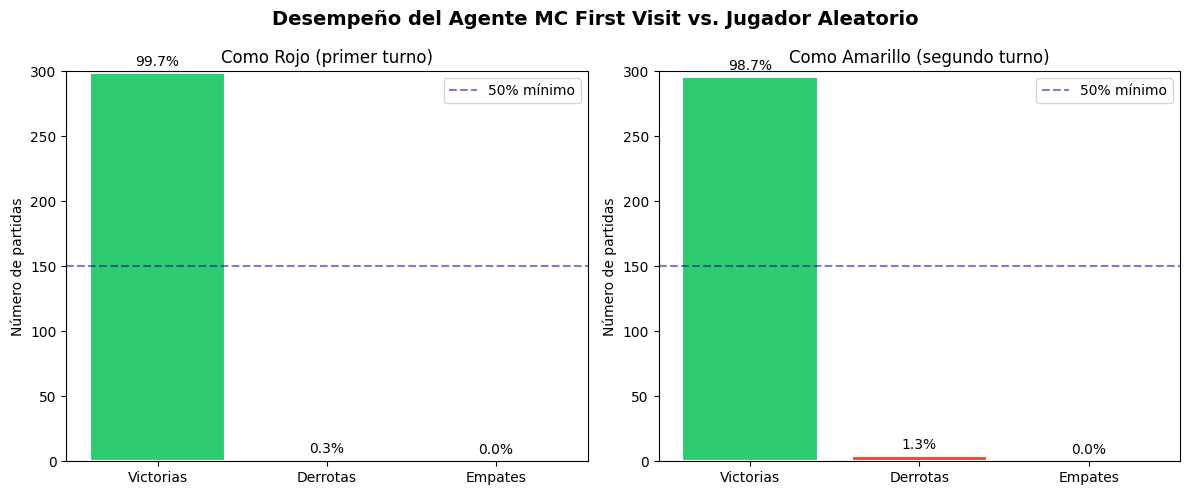

Gráfica 1 guardada.


In [7]:
# Gráfica 1: Resultados por color
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Desempeño del Agente MC First Visit vs. Jugador Aleatorio', fontsize=14, fontweight='bold')

colores_barra = ['#2ecc71', '#e74c3c', '#95a5a6']
etiquetas = ['Victorias', 'Derrotas', 'Empates']

for ax, resultado, titulo in zip(
    axes,
    [resultado_rojo, resultado_amarillo],
    ['Como Rojo (primer turno)', 'Como Amarillo (segundo turno)']
):
    valores = [resultado['victorias'], resultado['derrotas'], resultado['empates']]
    barras = ax.bar(etiquetas, valores, color=colores_barra, edgecolor='white', linewidth=1.5)
    ax.set_title(titulo, fontsize=12)
    ax.set_ylabel('Número de partidas')
    ax.set_ylim(0, N_PARTIDAS)
    ax.axhline(y=N_PARTIDAS * 0.5, color='navy', linestyle='--', alpha=0.5, label='50% mínimo')
    ax.legend()
    # Añadir porcentaje encima de cada barra
    for barra, val in zip(barras, valores):
        ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 3,
                f'{val/N_PARTIDAS*100:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('grafica_1_vs_aleatorio.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica 1 guardada.')

---
## 3. Análisis de Autodesempeño (Agente vs. Sí Mismo)

Aquí se enfrenta el agente contra una copia de sí mismo. Esto permite entender si la estrategia es robusta o si depende del oponente débil.

In [8]:
agente_mc_1 = MCFirstVisitAgent(num_rollouts=5, epsilon=0.1, use_blocking=True)
agente_mc_2 = MCFirstVisitAgent(num_rollouts=5, epsilon=0.1, use_blocking=True)

print('=== MC vs MC (autodesempeño) ===')
resultado_auto = evaluar(agente_mc_1, agente_mc_2, n_partidas=N_PARTIDAS, player1=-1)
print(f"  Victorias A1: {resultado_auto['victorias']} ({resultado_auto['tasa_victoria']*100:.1f}%)")
print(f"  Victorias A2: {resultado_auto['derrotas']} ({resultado_auto['tasa_derrota']*100:.1f}%)")
print(f"  Empates:      {resultado_auto['empates']}")
print()
print('Nota: En autodesempeño se espera ~50% victorias para cada jugador (juego simétrico).')
print('Si hay un sesgo de color (rojo/amarillo), indica ventaja posicional.')

=== MC vs MC (autodesempeño) ===


  Victorias A1: 145 (48.3%)
  Victorias A2: 148 (49.3%)
  Empates:      7

Nota: En autodesempeño se espera ~50% victorias para cada jugador (juego simétrico).
Si hay un sesgo de color (rojo/amarillo), indica ventaja posicional.


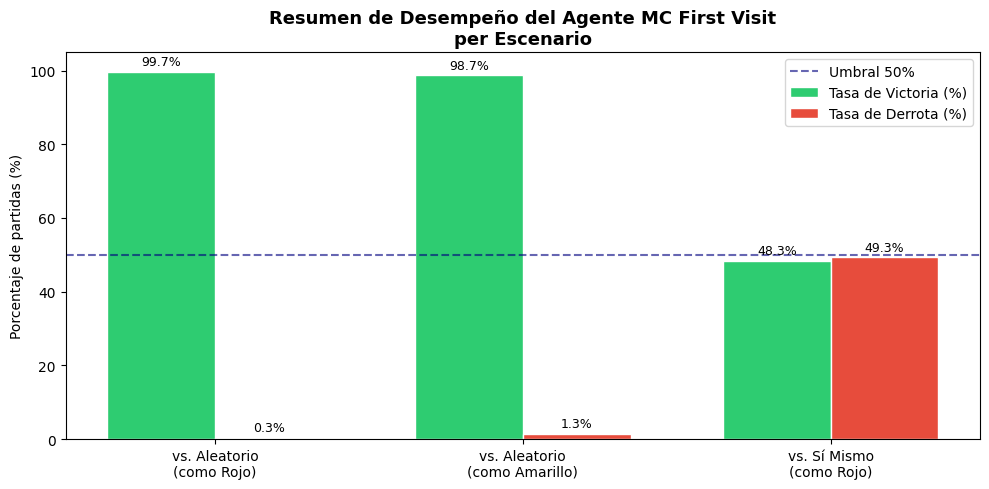

Gráfica 2 guardada.


In [9]:
# Gráfica 2: Comparación VS Aleatorio (ambos colores) VS Sí mismo
fig, ax = plt.subplots(figsize=(10, 5))

escenarios = ['vs. Aleatorio\n(como Rojo)', 'vs. Aleatorio\n(como Amarillo)', 'vs. Sí Mismo\n(como Rojo)']
tasas_victoria = [
    resultado_rojo['tasa_victoria'],
    resultado_amarillo['tasa_victoria'],
    resultado_auto['tasa_victoria']
]
tasas_derrota = [
    resultado_rojo['tasa_derrota'],
    resultado_amarillo['tasa_derrota'],
    resultado_auto['tasa_derrota']
]

x = np.arange(len(escenarios))
ancho = 0.35

b1 = ax.bar(x - ancho/2, [v*100 for v in tasas_victoria], ancho, label='Tasa de Victoria (%)', color='#2ecc71', edgecolor='white')
b2 = ax.bar(x + ancho/2, [v*100 for v in tasas_derrota], ancho, label='Tasa de Derrota (%)', color='#e74c3c', edgecolor='white')

ax.axhline(y=50, color='navy', linestyle='--', alpha=0.6, label='Umbral 50%')
ax.set_title('Resumen de Desempeño del Agente MC First Visit\nper Escenario', fontsize=13, fontweight='bold')
ax.set_ylabel('Porcentaje de partidas (%)')
ax.set_xticks(x)
ax.set_xticklabels(escenarios, fontsize=10)
ax.set_ylim(0, 105)
ax.legend()

for barra in list(b1) + list(b2):
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 1,
            f'{barra.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('grafica_2_resumen_escenarios.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica 2 guardada.')

---
## 4. Análisis en Función de `num_rollouts` (Variable de Configuración)

`num_rollouts` controla cuántas simulaciones aleatorias se hacen por movimiento candidato. Es la **variable de recursos** principal del agente: más rollouts = más información = más tiempo de cómputo.

In [10]:
import time

valores_rollouts = [1, 3, 5, 10, 20]
N_EVAL = 150  # partidas por configuración (reducido para velocidad)

resultados_rollouts = {}

for nr in valores_rollouts:
    print(f'Evaluando num_rollouts={nr}...')
    agente = MCFirstVisitAgent(num_rollouts=nr, epsilon=0.1, use_blocking=True)
    rand = RandomAgent()
    t0 = time.time()
    res = evaluar(agente, rand, n_partidas=N_EVAL, player1=-1)
    t1 = time.time()
    res['tiempo_total'] = t1 - t0
    res['tiempo_por_partida'] = (t1 - t0) / N_EVAL
    resultados_rollouts[nr] = res
    print(f'  -> Victoria: {res["tasa_victoria"]*100:.1f}%  |  Tiempo: {t1-t0:.2f}s')

print('\nEvaluación completada.')

Evaluando num_rollouts=1...


  -> Victoria: 98.0%  |  Tiempo: 12.78s
Evaluando num_rollouts=3...


  -> Victoria: 100.0%  |  Tiempo: 35.27s
Evaluando num_rollouts=5...


  -> Victoria: 100.0%  |  Tiempo: 50.75s
Evaluando num_rollouts=10...


  -> Victoria: 99.3%  |  Tiempo: 111.96s
Evaluando num_rollouts=20...


  -> Victoria: 98.7%  |  Tiempo: 208.25s

Evaluación completada.


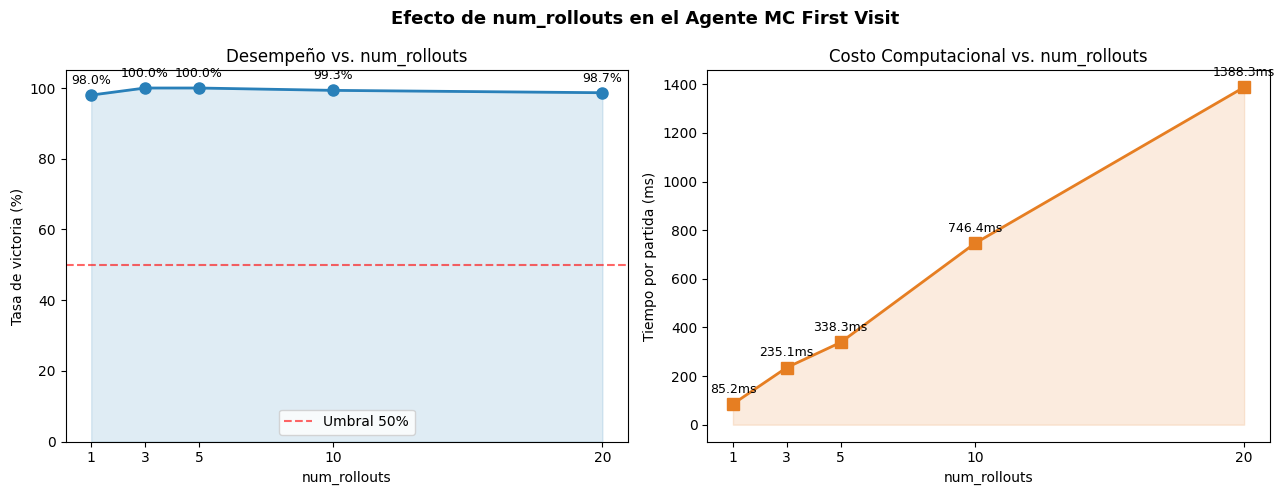

Gráfica 3 guardada.


In [11]:
# Gráfica 3: Tasa de victoria y tiempo en función de num_rollouts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Efecto de num_rollouts en el Agente MC First Visit', fontsize=13, fontweight='bold')

tasas = [resultados_rollouts[nr]['tasa_victoria'] * 100 for nr in valores_rollouts]
tiempos = [resultados_rollouts[nr]['tiempo_por_partida'] * 1000 for nr in valores_rollouts]  # en ms

# Panel izquierdo: tasa de victoria
ax1.plot(valores_rollouts, tasas, marker='o', color='#2980b9', linewidth=2, markersize=8)
ax1.fill_between(valores_rollouts, tasas, alpha=0.15, color='#2980b9')
ax1.axhline(y=50, color='red', linestyle='--', alpha=0.6, label='Umbral 50%')
ax1.set_xlabel('num_rollouts')
ax1.set_ylabel('Tasa de victoria (%)')
ax1.set_title('Desempeño vs. num_rollouts')
ax1.set_ylim(0, 105)
ax1.set_xticks(valores_rollouts)
ax1.legend()
for x, y in zip(valores_rollouts, tasas):
    ax1.annotate(f'{y:.1f}%', (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)

# Panel derecho: tiempo por partida
ax2.plot(valores_rollouts, tiempos, marker='s', color='#e67e22', linewidth=2, markersize=8)
ax2.fill_between(valores_rollouts, tiempos, alpha=0.15, color='#e67e22')
ax2.set_xlabel('num_rollouts')
ax2.set_ylabel('Tiempo por partida (ms)')
ax2.set_title('Costo Computacional vs. num_rollouts')
ax2.set_xticks(valores_rollouts)
for x, y in zip(valores_rollouts, tiempos):
    ax2.annotate(f'{y:.1f}ms', (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('grafica_3_rollouts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica 3 guardada.')

---
## 5. Comparación de Versiones: Con y Sin Bloqueo

Se comparan **dos versiones** del agente:
- **Versión A**: MC First Visit con bloqueo activado (`use_blocking=True`)
- **Versión B**: MC First Visit sin bloqueo (`use_blocking=False`)

Esto evalúa el aporte real de la sub-estrategia de bloqueo.

In [12]:
N_COMP = 200

print('=== Versión CON bloqueo vs. Aleatorio (Rojo) ===')
v_con_bloqueo_rojo = evaluar(
    MCFirstVisitAgent(num_rollouts=5, epsilon=0.1, use_blocking=True),
    RandomAgent(), n_partidas=N_COMP, player1=-1
)
print(f"  Victoria: {v_con_bloqueo_rojo['tasa_victoria']*100:.1f}%")

print('=== Versión SIN bloqueo vs. Aleatorio (Rojo) ===')
v_sin_bloqueo_rojo = evaluar(
    MCFirstVisitAgent(num_rollouts=5, epsilon=0.1, use_blocking=False),
    RandomAgent(), n_partidas=N_COMP, player1=-1
)
print(f"  Victoria: {v_sin_bloqueo_rojo['tasa_victoria']*100:.1f}%")

print()
print('=== Versión CON bloqueo vs. Aleatorio (Amarillo) ===')
v_con_bloqueo_amar = evaluar(
    MCFirstVisitAgent(num_rollouts=5, epsilon=0.1, use_blocking=True),
    RandomAgent(), n_partidas=N_COMP, player1=1
)
print(f"  Victoria: {v_con_bloqueo_amar['tasa_victoria']*100:.1f}%")

print('=== Versión SIN bloqueo vs. Aleatorio (Amarillo) ===')
v_sin_bloqueo_amar = evaluar(
    MCFirstVisitAgent(num_rollouts=5, epsilon=0.1, use_blocking=False),
    RandomAgent(), n_partidas=N_COMP, player1=1
)
print(f"  Victoria: {v_sin_bloqueo_amar['tasa_victoria']*100:.1f}%")

=== Versión CON bloqueo vs. Aleatorio (Rojo) ===


  Victoria: 100.0%
=== Versión SIN bloqueo vs. Aleatorio (Rojo) ===


  Victoria: 97.0%

=== Versión CON bloqueo vs. Aleatorio (Amarillo) ===


  Victoria: 97.5%
=== Versión SIN bloqueo vs. Aleatorio (Amarillo) ===


  Victoria: 93.0%


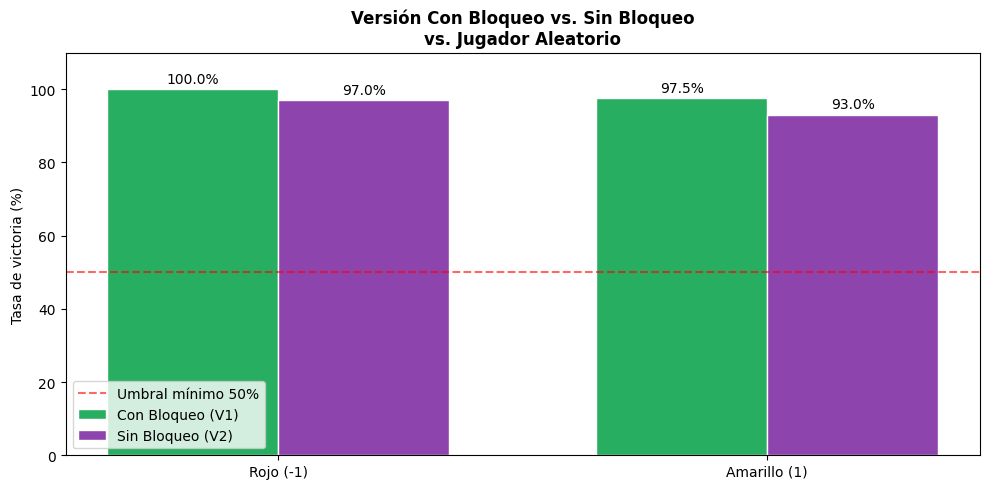

Gráfica 4 guardada.


In [13]:
# Gráfica 4: Comparación de versiones por color
fig, ax = plt.subplots(figsize=(10, 5))

categorias = ['Rojo (-1)', 'Amarillo (1)']
con_bloqueo = [
    v_con_bloqueo_rojo['tasa_victoria'] * 100,
    v_con_bloqueo_amar['tasa_victoria'] * 100
]
sin_bloqueo = [
    v_sin_bloqueo_rojo['tasa_victoria'] * 100,
    v_sin_bloqueo_amar['tasa_victoria'] * 100
]

x = np.arange(len(categorias))
ancho = 0.35

b1 = ax.bar(x - ancho/2, con_bloqueo, ancho, label='Con Bloqueo (V1)', color='#27ae60', edgecolor='white')
b2 = ax.bar(x + ancho/2, sin_bloqueo, ancho, label='Sin Bloqueo (V2)', color='#8e44ad', edgecolor='white')

ax.axhline(y=50, color='red', linestyle='--', alpha=0.6, label='Umbral mínimo 50%')
ax.set_title('Versión Con Bloqueo vs. Sin Bloqueo\nvs. Jugador Aleatorio', fontsize=12, fontweight='bold')
ax.set_ylabel('Tasa de victoria (%)')
ax.set_xticks(x)
ax.set_xticklabels(categorias)
ax.set_ylim(0, 110)
ax.legend()

for barra in list(b1) + list(b2):
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 1,
            f'{barra.get_height():.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('grafica_4_versiones.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica 4 guardada.')

---
## 6. Evolución del Aprendizaje (Q-table) a lo Largo del Tiempo

Se analiza cómo crece el tamaño de la Q-table y cómo mejora la tasa de victoria en ventanas de partidas consecutivas.

In [14]:
TOTAL_PARTIDAS = 500
VENTANA = 50  # evaluar cada 50 partidas

agente_evol = MCFirstVisitAgent(num_rollouts=5, epsilon=0.1, use_blocking=True)
rand_evol = RandomAgent()

tasas_evolucion = []
tamanos_qtable = []
checkpoints = []

print('Simulando evolución del aprendizaje...')
for checkpoint in range(VENTANA, TOTAL_PARTIDAS + 1, VENTANA):
    # Jugar una ventana de partidas
    wins = 0
    for _ in range(VENTANA):
        r = jugar_partida(agente_evol, rand_evol, player1=-1)
        if r == 1:
            wins += 1
    tasas_evolucion.append(wins / VENTANA * 100)
    tamanos_qtable.append(len(agente_evol.q_table))
    checkpoints.append(checkpoint)
    print(f'  Partida {checkpoint:4d}: Victoria={wins/VENTANA*100:.1f}% | Q-table={len(agente_evol.q_table)} entradas')

print('\nEvolución completada.')

Simulando evolución del aprendizaje...
  Partida   50: Victoria=100.0% | Q-table=259 entradas
  Partida  100: Victoria=98.0% | Q-table=511 entradas
  Partida  150: Victoria=100.0% | Q-table=769 entradas
  Partida  200: Victoria=98.0% | Q-table=1023 entradas
  Partida  250: Victoria=100.0% | Q-table=1245 entradas
  Partida  300: Victoria=100.0% | Q-table=1472 entradas
  Partida  350: Victoria=98.0% | Q-table=1699 entradas
  Partida  400: Victoria=98.0% | Q-table=1910 entradas
  Partida  450: Victoria=100.0% | Q-table=2116 entradas
  Partida  500: Victoria=98.0% | Q-table=2358 entradas

Evolución completada.


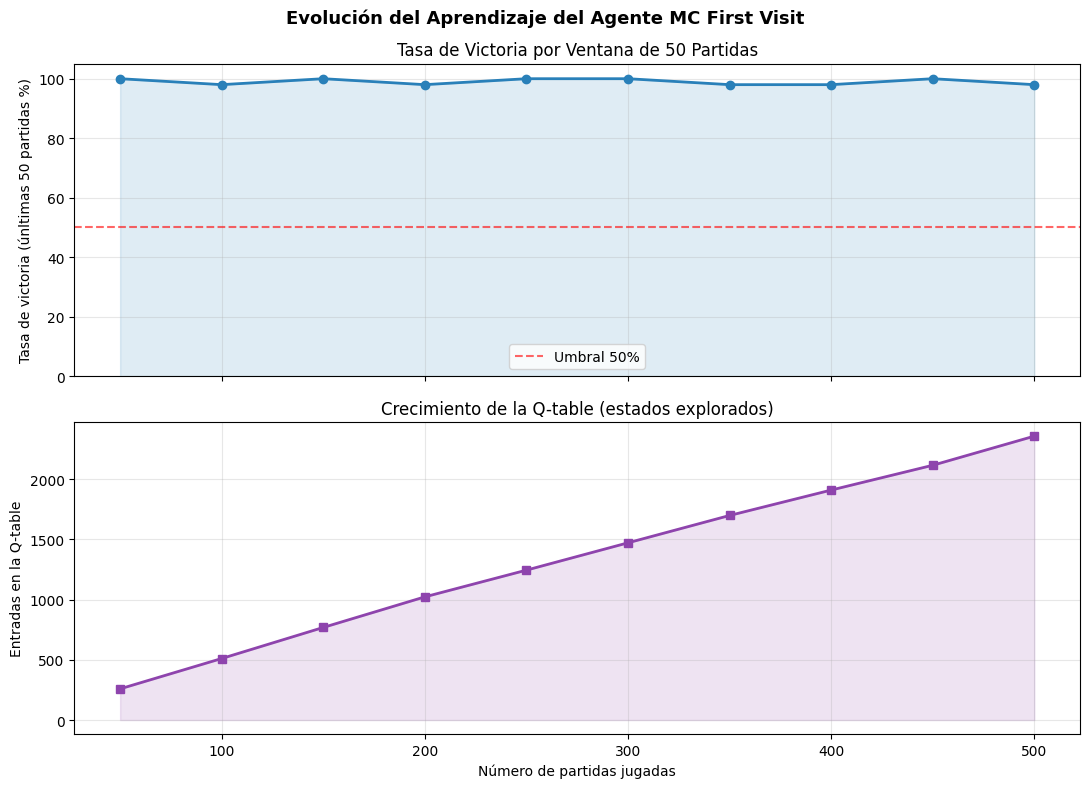

Gráfica 5 guardada.


In [15]:
# Gráfica 5: Evolución del aprendizaje
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
fig.suptitle('Evolución del Aprendizaje del Agente MC First Visit', fontsize=13, fontweight='bold')

# Panel superior: tasa de victoria por ventana
ax1.plot(checkpoints, tasas_evolucion, marker='o', color='#2980b9', linewidth=2, markersize=6)
ax1.fill_between(checkpoints, tasas_evolucion, alpha=0.15, color='#2980b9')
ax1.axhline(y=50, color='red', linestyle='--', alpha=0.6, label='Umbral 50%')
ax1.set_ylabel('Tasa de victoria (\u00fanltimas 50 partidas %)')
ax1.set_title('Tasa de Victoria por Ventana de 50 Partidas')
ax1.set_ylim(0, 105)
ax1.legend()
ax1.grid(alpha=0.3)

# Panel inferior: tamaño de la Q-table
ax2.plot(checkpoints, tamanos_qtable, marker='s', color='#8e44ad', linewidth=2, markersize=6)
ax2.fill_between(checkpoints, tamanos_qtable, alpha=0.15, color='#8e44ad')
ax2.set_xlabel('Número de partidas jugadas')
ax2.set_ylabel('Entradas en la Q-table')
ax2.set_title('Crecimiento de la Q-table (estados explorados)')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('grafica_5_evolucion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica 5 guardada.')

---
## 7. Resumen de Resultados

In [16]:
print('='*60)
print('       RESUMEN FINAL DE RESULTADOS')
print('='*60)
print(f"\nVS Aleatorio — como Rojo   : {resultado_rojo['tasa_victoria']*100:.1f}% victorias")
print(f"VS Aleatorio — como Amarillo: {resultado_amarillo['tasa_victoria']*100:.1f}% victorias")
print(f"VS Sí Mismo  — como Rojo   : {resultado_auto['tasa_victoria']*100:.1f}% victorias")
print()
print('Efecto de num_rollouts:')
for nr in valores_rollouts:
    r = resultados_rollouts[nr]
    print(f"  rollouts={nr:2d}: {r['tasa_victoria']*100:.1f}% victoria | {r['tiempo_por_partida']*1000:.1f}ms/partida")
print()
print(f"Con bloqueo   — Rojo:    {v_con_bloqueo_rojo['tasa_victoria']*100:.1f}%")
print(f"Sin bloqueo   — Rojo:    {v_sin_bloqueo_rojo['tasa_victoria']*100:.1f}%")
print(f"Con bloqueo   — Amarillo:{v_con_bloqueo_amar['tasa_victoria']*100:.1f}%")
print(f"Sin bloqueo   — Amarillo:{v_sin_bloqueo_amar['tasa_victoria']*100:.1f}%")
print('='*60)

       RESUMEN FINAL DE RESULTADOS

VS Aleatorio — como Rojo   : 99.7% victorias
VS Aleatorio — como Amarillo: 98.7% victorias
VS Sí Mismo  — como Rojo   : 48.3% victorias

Efecto de num_rollouts:
  rollouts= 1: 98.0% victoria | 85.2ms/partida
  rollouts= 3: 100.0% victoria | 235.1ms/partida
  rollouts= 5: 100.0% victoria | 338.3ms/partida
  rollouts=10: 99.3% victoria | 746.4ms/partida
  rollouts=20: 98.7% victoria | 1388.3ms/partida

Con bloqueo   — Rojo:    100.0%
Sin bloqueo   — Rojo:    97.0%
Con bloqueo   — Amarillo:97.5%
Sin bloqueo   — Amarillo:93.0%


---
## 8. Propuesta de Mejora

### Debilidades identificadas

**1. Explosión del espacio de estados**  
La Q-table crece sin límite con cada nuevo estado visitado. Connect-4 tiene ~4.5 trillones de estados posibles, por lo que la Q-table solo cubre una fracción ínfima. Esto limita la generalización: el agente no transfiere conocimiento aprendido a tableros similares.

**2. Rollouts son completamente aleatorios**  
La calidad de las simulaciones depende de movimientos al azar, lo que introduce alta varianza en las estimaciones. Un oponente fuerte puede explotar patrones que el rollout aleatorio no detecta.

**3. Sin memoria entre partidas del torneo**  
La Q-table actual es `q_table = {}` a nivel de clase; si el entorno la resetea entre partidas, el agente pierde todo lo aprendido.

### Mejoras propuestas

**Mejora 1 — Función de valor por red neuronal (DQN)**  
Reemplazar la Q-table por una red neuronal pequeña que reciba el tablero (42 valores) y prediga el valor Q de cada columna. Esto permite **generalización**: tableros similares comparten conocimiento. Se espera que reduzca la varianza del estimador y mejore el desempeño con menos partidas de entrenamiento.

**Mejora 2 — Rollouts guiados (no aleatorios)**  
En lugar de elegir movimientos aleatoriamente durante el rollout, aplicar una heurística simple (ej: priorizar victorias inmediatas del jugador actual dentro del rollout). Esto reduciría la varianza del estimador de retorno y requeriría menos rollouts para obtener estimaciones precisas.

**Relación causa-efecto:**  
La alta varianza de los rollouts aleatorios hace que con pocos rollouts (`num_rollouts < 5`) el agente tome decisiones subóptimas. Al guiar los rollouts, un valor de `num_rollouts=3` podría rendir igual o mejor que `num_rollouts=10` actual, reduciendo el costo computacional a la mitad.

In [17]:
print('Notebook de entrega completado exitosamente.')
print('Gráficas generadas:')
print('  grafica_1_vs_aleatorio.png')
print('  grafica_2_resumen_escenarios.png')
print('  grafica_3_rollouts.png')
print('  grafica_4_versiones.png')
print('  grafica_5_evolucion.png')

Notebook de entrega completado exitosamente.
Gráficas generadas:
  grafica_1_vs_aleatorio.png
  grafica_2_resumen_escenarios.png
  grafica_3_rollouts.png
  grafica_4_versiones.png
  grafica_5_evolucion.png
